# 05 — Advanced Modeling
## Gradient Boosting: Liệu Có Vượt Qua Baseline?

**Bối cảnh từ NB04**: Baseline models đã thiết lập một "ceiling" khá cao:

| Model | Accuracy (CV) | F1 | Vai trò |
|-------|-------------|------|---------|
| **Logistic Regression** | 0.9376 ± 0.0019 | 0.8243 | **Best Baseline** |
| SVM (linear) | 0.9367 ± 0.0021 | 0.8230 | Runner-up |
| Random Forest (200 trees) | 0.9364 ± 0.0014 | 0.8208 | Best tree-based |
| Decision Tree (depth=10) | 0.9292 ± 0.0010 | 0.8011 | Weakest |

**Câu hỏi**: Ba model hàng đầu đạt performance rất sát nhau (~93.6-93.8%). Liệu **gradient boosting** (XGBoost, LightGBM) có phá vỡ được ceiling này nhờ khả năng khai thác tốt hơn các tương tác phi tuyến?

**Mục tiêu**:
1. Train và tuning thủ công **XGBoost** — gradient boosting + regularization
2. Train và tuning thủ công **LightGBM** — leaf-wise growth, nhanh hơn
3. So sánh trực tiếp với **tất cả baseline** từ NB04
4. Chọn ra **best overall model** để chuyển sang NB06 (Evaluation + SHAP)


## 5.1 Load Data & Setup

Phần này nạp dữ liệu cuối cùng từ `data/processed/train_final.*`, thiết lập `StratifiedKFold` và định nghĩa các utility functions dùng chung.

Cách tổ chức được giữ đồng nhất với notebook 04 để việc so sánh baseline và advanced models được nhất quán.


In [1]:
from pathlib import Path
import warnings
import os
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

import sys

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "Depression"

# Reproducibility setup for notebook-level randomness.
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from modeling_utils import evaluate_model_cv, manual_model_search

DATA_DIR = PROJECT_ROOT / "data" / "processed"
DOCS_DIR = PROJECT_ROOT / "docs"
DOCS_DIR.mkdir(parents=True, exist_ok=True)


def load_dataset(stem: str) -> pd.DataFrame:
    parquet_path = DATA_DIR / f"{stem}.parquet"
    csv_path = DATA_DIR / f"{stem}.csv"

    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f"Không tìm thấy {parquet_path} hoặc {csv_path}")


def show_metric_summary(metrics_dict: dict) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "Metric": ["Accuracy", "F1", "Precision", "Recall"],
            "Mean ± Std": [
                f"{metrics_dict['accuracy_mean']:.4f} ± {metrics_dict['accuracy_std']:.4f}",
                f"{metrics_dict['f1_mean']:.4f} ± {metrics_dict['f1_std']:.4f}",
                f"{metrics_dict['precision_mean']:.4f} ± {metrics_dict['precision_std']:.4f}",
                f"{metrics_dict['recall_mean']:.4f} ± {metrics_dict['recall_std']:.4f}",
            ],
        }
    )


def metrics_row(model_name: str, metrics_dict: dict, note: str) -> dict:
    return {
        "Model": model_name,
        "Accuracy_mean": metrics_dict["accuracy_mean"],
        "Accuracy_std": metrics_dict["accuracy_std"],
        "F1_mean": metrics_dict["f1_mean"],
        "Precision_mean": metrics_dict["precision_mean"],
        "Recall_mean": metrics_dict["recall_mean"],
        "Ghi chú": note,
    }


train_df = load_dataset("train_final")
test_df = load_dataset("test_final")

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET].astype(int)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"Number of features: {X.shape[1]}")
print("Target distribution (ratio):")
print(y.value_counts(normalize=True).rename("ratio").round(4))

display(train_df.head())

Train shape: (140700, 23)
Test shape : (93800, 22)
Number of features: 22
Target distribution (ratio):
Depression
0    0.8183
1    0.1817
Name: ratio, dtype: float64


,Age,Working Professional or Student,CGPA,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression,Pressure,Satisfaction,has_cgpa,City_te,Profession_te,Degree_te,stress_load,wellbeing_index,stress_satisfaction_ratio,hours_pressure_ratio,poor_sleep,cgpa_pressure,risk_score,age_group
0,49.0,1,0.00,3,2,0,1.0,2.0,0,5.0,2.0,0,0.186035,0.047461,0.171802,10.0,2.5,1.666667,5.0,0,0.00,0,2
1,26.0,1,0.00,0,0,1,7.0,3.0,1,4.0,3.0,0,0.137782,0.055411,0.150835,12.0,1.5,1.000000,28.0,1,0.00,1,0
2,33.0,0,8.97,1,2,1,3.0,1.0,1,5.0,2.0,1,0.159042,0.534109,0.116610,5.0,1.5,1.666667,15.0,0,44.85,1,1
3,22.0,1,0.00,0,1,1,10.0,1.0,1,5.0,1.0,0,0.130731,0.053929,0.132338,5.0,0.5,2.500000,50.0,1,0.00,2,0
4,30.0,1,0.00,1,0,1,9.0,4.0,0,1.0,1.0,0,0.121875,0.053860,0.132338,4.0,1.0,0.500000,9.0,0,0.00,2,1


### Nhận xét 5.1

- Dữ liệu đầu vào là **`train_final`** — đã qua preprocessing (NB02) và feature engineering (NB03), bao gồm 22 features.
- Việc dùng **cùng `random_state=42`** và **cùng `StratifiedKFold(n_splits=5)`** như NB04 là **crucial** để so sánh công bằng: mỗi fold chứa đúng những mẫu train/val giống nhau, nên sự khác biệt performance **hoàn toàn đến từ mô hình**, không phải từ cách chia dữ liệu.
- Từ thời điểm này, mọi cải thiện về performance chủ yếu đến từ khả năng mô hình hóa — gradient boosting sẽ có lợi thế ở các non-linear interactions mà LR chưa khai thác hết.


## 5.2 XGBoost

XGBoost là một biến thể gradient boosting có thêm regularization để kiểm soát độ phức tạp của cây.

Công thức objective:

$$
\mathcal{L}(\theta) = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k), \quad
\Omega(f) = \gamma T + \frac{1}{2}\lambda\|\mathbf{w}\|^2
$$

Trong đó:
- $l(y_i, \hat{y}_i)$ là loss trên từng mẫu
- $T$ là số lá của cây
- $\gamma$ phạt số lượng lá quá lớn
- $\lambda$ phạt trọng số lá quá lớn

**Ý nghĩa**: regularization term giúp mô hình tránh overfitting bằng cách không cho cây phát triển quá phức tạp.


In [2]:
# Factory function for reproducible XGBoost models during CV and manual tuning.
def build_xgb_classifier(max_depth=6, learning_rate=0.1, n_estimators=300):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=1,
        reg_alpha=0.0,
        reg_lambda=1.0,
    )

# Evaluate a default configuration first to set a performance baseline.
xgb_initial_model = build_xgb_classifier()
xgb_initial_metrics = evaluate_model_cv(
    estimator=xgb_initial_model,
    X=X,
    y=y,
    cv=cv,
)

print("Aggregated metrics for XGBoost (initial params):")
display(show_metric_summary(xgb_initial_metrics))

# Define a compact grid and run manual search for best XGBoost settings.
xgb_param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [250, 400],
}

xgb_results_df, best_xgb_params, best_xgb_metrics = manual_model_search(
    model_factory=build_xgb_classifier,
    param_grid=xgb_param_grid,
    X=X,
    y=y,
    cv=cv,
)

print("Manual tuning results for XGBoost:")
display(
    xgb_results_df[
        [
            "trial",
            "max_depth",
            "learning_rate",
            "n_estimators",
            "accuracy_mean",
            "accuracy_std",
            "f1_mean",
            "precision_mean",
            "recall_mean",
        ]
    ].round(4)
)

# Report the best parameter set and its aggregated CV performance.
print("Best XGBoost params:", best_xgb_params)
display(show_metric_summary(best_xgb_metrics))

Aggregated metrics for XGBoost (initial params):


,Metric,Mean ± Std
0,Accuracy,0.9381 ± 0.0017
1,F1,0.8270 ± 0.0049
2,Precision,0.8399 ± 0.0043
3,Recall,0.8145 ± 0.0061


Manual tuning results for XGBoost:


,trial,max_depth,learning_rate,n_estimators,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,5,4,0.10,250,0.9395,0.0016,0.8311,0.8431,0.8195
1,2,4,0.05,400,0.9394,0.0013,0.8308,0.8436,0.8184
2,6,4,0.10,400,0.9393,0.0013,0.8306,0.8425,0.8189
3,1,4,0.05,250,0.9391,0.0012,0.8299,0.8433,0.8169
4,3,6,0.05,250,0.9390,0.0015,0.8299,0.8419,0.8182
5,4,6,0.05,400,0.9386,0.0016,0.8287,0.8402,0.8176
6,7,6,0.10,250,0.9383,0.0015,0.8277,0.8406,0.8152
7,8,6,0.10,400,0.9374,0.0014,0.8251,0.8376,0.8129


Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 250}


,Metric,Mean ± Std
0,Accuracy,0.9395 ± 0.0016
1,F1,0.8311 ± 0.0045
2,Precision,0.8431 ± 0.0037
3,Recall,0.8195 ± 0.0056


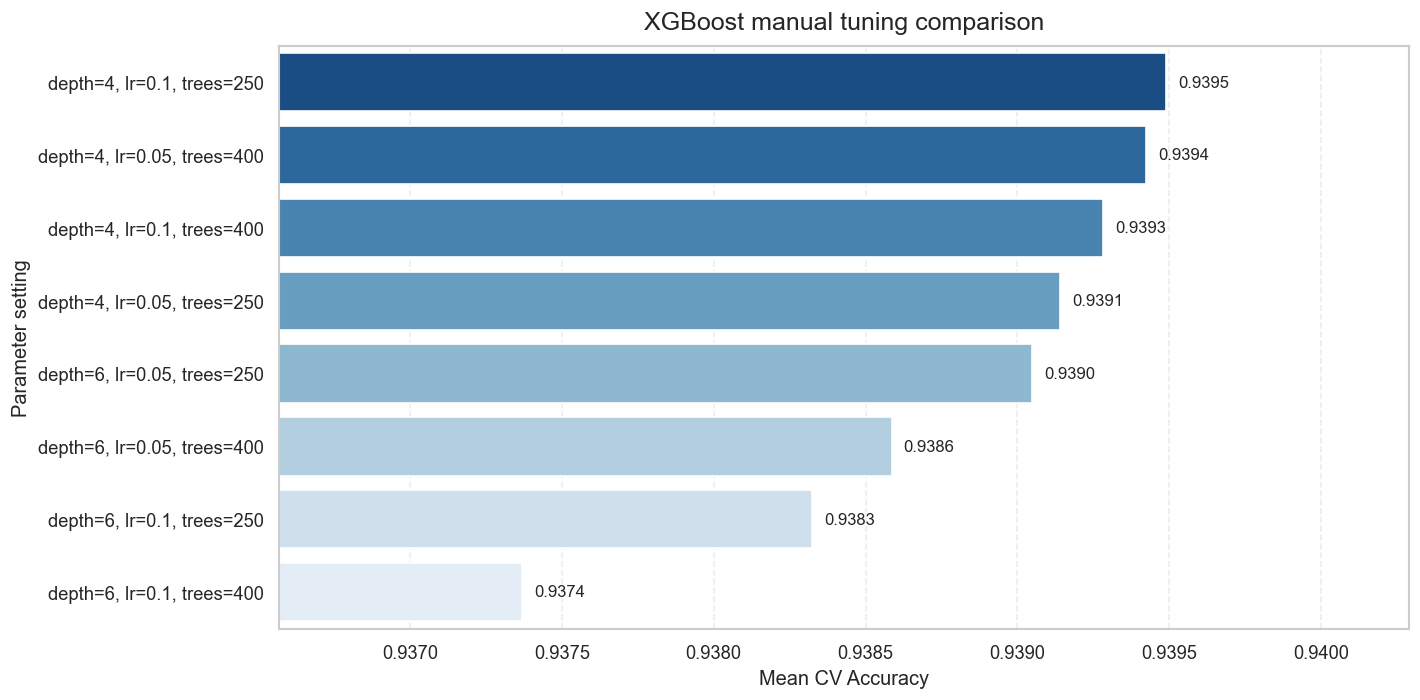

In [3]:
# Sort candidate settings by mean CV accuracy for plotting.
xgb_plot_df = xgb_results_df.sort_values("accuracy_mean", ascending=False).copy()
xgb_plot_df["setting"] = xgb_plot_df.apply(
    lambda row: f"depth={row['max_depth']}, lr={row['learning_rate']}, trees={row['n_estimators']}",
    axis=1,
)

# Build a horizontal comparison chart so tuning results are easy to scan.
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
sns.barplot(
    data=xgb_plot_df,
    x="accuracy_mean",
    y="setting",
    palette="Blues_r",
    ax=ax,
)

# Use a tight x-range around scores to make small differences visible.
x_min = float(xgb_plot_df["accuracy_mean"].min())
x_max = float(xgb_plot_df["accuracy_mean"].max())
margin = max((x_max - x_min) * 0.35, 0.0008)
ax.set_xlim(max(0.0, x_min - margin), min(1.0, x_max + margin))

ax.set_title("XGBoost manual tuning comparison", fontsize=15, pad=10)
ax.set_xlabel("Mean CV Accuracy", fontsize=12)
ax.set_ylabel("Parameter setting", fontsize=12)
ax.tick_params(axis="both", labelsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.35)

# Annotate each bar with exact score to support report writing.
for idx, row in xgb_plot_df.reset_index(drop=True).iterrows():
    ax.text(
        row["accuracy_mean"] + margin * 0.05,
        idx,
        f"{row['accuracy_mean']:.4f}",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig('../scripts/img/05_model_advanced/05_model_advanced_fig1.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhận xét 5.2 — XGBoost

- Cấu hình khởi tạo đã đạt `Accuracy = 0.9381 ± 0.0017`, `F1 = 0.8270 ± 0.0049` — **ngay lập tức vượt qua baseline ceiling** (LR: 0.9376). Đây là dấu hiệu tích cực cho thấy gradient boosting thực sự capture thêm signal.
- Sau manual tuning trên `max_depth`, `learning_rate`, `n_estimators`, cấu hình tốt nhất: **`max_depth=4, learning_rate=0.1, n_estimators=250`** với `Accuracy = 0.9395 ± 0.0016` và `F1 = 0.8311 ± 0.0045`.
- **Insight từ tuning**: Cấu hình tốt nhất dùng `max_depth=4` thay vì `6` — **cây nông hơn + nhiều cây hơn** tốt hơn cây sâu + ít cây. Đây là bằng chứng thực nghiệm cho vai trò của regularization $\Omega(f) = \gamma T + \frac{1}{2}\lambda\|\mathbf{w}\|^2$: kiểm soát độ phức tạp giúp mô hình tổng quát hóa tốt hơn.
- **So sánh với baseline**: XGBoost nhỉnh hơn LR `+0.0019` accuracy — mức cải thiện không lớn nhưng **nhất quán** trên cả Accuracy và F1, cho thấy boosting thực sự khai thác thêm interaction patterns (đặc biệt `stress_load`, `risk_score`, `cgpa_pressure`) mà mô hình tuyến tính bỏ qua.
- Với phân phối lớp 82:18, mức cải thiện khoảng 0.19% accuracy vẫn là một cải thiện có ý nghĩa trong bối cảnh sức khỏe tâm thần.


## 5.3 LightGBM

LightGBM cũng là mô hình gradient boosting nhưng sử dụng chiến lược phát triển cây **leaf-wise**, thường giúp giảm loss nhanh hơn.

Công thức cập nhật:

$$
F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})
$$

Trong đó:
- $F_{m-1}(\mathbf{x})$ là mô hình ở vòng trước
- $h_m(\mathbf{x})$ là weak learner mới
- $\eta$ là **learning rate**

**Giải thích learning rate $\eta$**:
- $\eta$ nhỏ giúp mô hình học chậm nhưng ổn định hơn
- $\eta$ lớn giúp hội tụ nhanh hơn nhưng dễ overfit

**Vì sao LightGBM thường nhanh hơn XGBoost?**
- LightGBM dùng **leaf-wise growth**
- XGBoost thường gần với **level-wise growth**
- Với dữ liệu tabular lớn, leaf-wise thường tối ưu loss hiệu quả hơn cho cùng số node


In [4]:
# Factory function for LightGBM to keep CV/tuning runs reproducible and consistent.
def build_lgbm_classifier(num_leaves=31, learning_rate=0.1, n_estimators=300):
    return LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=1,
        deterministic=True,
        force_col_wise=True,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=0.0,
        verbose=-1,
    )

# Evaluate default LightGBM configuration as reference before tuning.
lgbm_initial_model = build_lgbm_classifier()
lgbm_initial_metrics = evaluate_model_cv(
    estimator=lgbm_initial_model,
    X=X,
    y=y,
    cv=cv,
)

print("Aggregated metrics for LightGBM (initial params):")
display(show_metric_summary(lgbm_initial_metrics))

# Search a compact hyperparameter space for the best LightGBM setting.
lgbm_param_grid = {
    "num_leaves": [31, 63],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [250, 400],
}

lgbm_results_df, best_lgbm_params, best_lgbm_metrics = manual_model_search(
    model_factory=build_lgbm_classifier,
    param_grid=lgbm_param_grid,
    X=X,
    y=y,
    cv=cv,
)

print("Manual tuning results for LightGBM:")
display(
    lgbm_results_df[
        [
            "trial",
            "num_leaves",
            "learning_rate",
            "n_estimators",
            "accuracy_mean",
            "accuracy_std",
            "f1_mean",
            "precision_mean",
            "recall_mean",
        ]
    ].round(4)
)

# Report the best LightGBM configuration for downstream comparison.
print("Best LightGBM params:", best_lgbm_params)
display(show_metric_summary(best_lgbm_metrics))

Aggregated metrics for LightGBM (initial params):


,Metric,Mean ± Std
0,Accuracy,0.9384 ± 0.0014
1,F1,0.8283 ± 0.0041
2,Precision,0.8388 ± 0.0037
3,Recall,0.8180 ± 0.0057


Manual tuning results for LightGBM:


,trial,num_leaves,learning_rate,n_estimators,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,1,31,0.05,250,0.9392,0.0013,0.8306,0.8417,0.8198
1,3,31,0.05,400,0.9391,0.0015,0.8301,0.8413,0.8192
2,2,63,0.05,250,0.9389,0.0014,0.8296,0.8410,0.8184
3,4,63,0.05,400,0.9386,0.0014,0.8287,0.8406,0.8171
4,5,31,0.10,250,0.9385,0.0015,0.8287,0.8394,0.8184
5,7,31,0.10,400,0.9382,0.0015,0.8279,0.8383,0.8179
6,6,63,0.10,250,0.9381,0.0015,0.8274,0.8379,0.8171
7,8,63,0.10,400,0.9373,0.0016,0.8249,0.8376,0.8127


Best LightGBM params: {'learning_rate': 0.05, 'n_estimators': 250, 'num_leaves': 31}


,Metric,Mean ± Std
0,Accuracy,0.9392 ± 0.0013
1,F1,0.8306 ± 0.0040
2,Precision,0.8417 ± 0.0036
3,Recall,0.8198 ± 0.0053


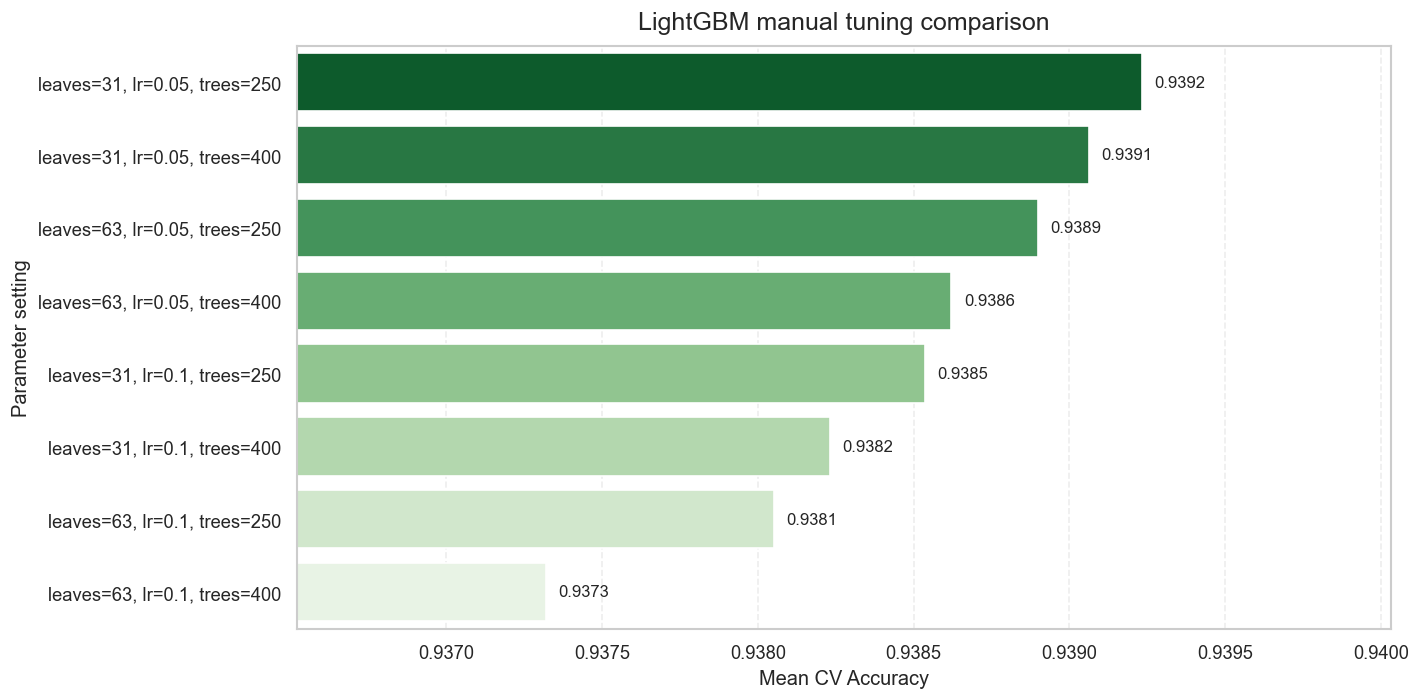

In [5]:
# Sort LightGBM trials by accuracy and build readable setting labels.
lgbm_plot_df = lgbm_results_df.sort_values("accuracy_mean", ascending=False).copy()
lgbm_plot_df["setting"] = lgbm_plot_df.apply(
    lambda row: f"leaves={row['num_leaves']}, lr={row['learning_rate']}, trees={row['n_estimators']}",
    axis=1,
)

# Plot all LightGBM tuning trials to compare gains across configurations.
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
sns.barplot(
    data=lgbm_plot_df,
    x="accuracy_mean",
    y="setting",
    palette="Greens_r",
    ax=ax,
)

# Zoom x-axis around observed values so tiny metric gaps are still visible.
x_min = float(lgbm_plot_df["accuracy_mean"].min())
x_max = float(lgbm_plot_df["accuracy_mean"].max())
margin = max((x_max - x_min) * 0.35, 0.0008)
ax.set_xlim(max(0.0, x_min - margin), min(1.0, x_max + margin))

ax.set_title("LightGBM manual tuning comparison", fontsize=15, pad=10)
ax.set_xlabel("Mean CV Accuracy", fontsize=12)
ax.set_ylabel("Parameter setting", fontsize=12)
ax.tick_params(axis="both", labelsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.35)

# Annotate bars with exact accuracy to simplify report extraction.
for idx, row in lgbm_plot_df.reset_index(drop=True).iterrows():
    ax.text(
        row["accuracy_mean"] + margin * 0.05,
        idx,
        f"{row['accuracy_mean']:.4f}",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig('../scripts/img/05_model_advanced/05_model_advanced_fig2.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhận xét 5.3 — LightGBM

- Cấu hình khởi tạo đạt `Accuracy = 0.9384 ± 0.0014`, `F1 = 0.8283 ± 0.0041` — cũng **vượt baseline** và bám sát XGBoost ngay từ default params.
- Sau manual tuning, cấu hình tốt nhất: **`num_leaves=31, learning_rate=0.05, n_estimators=250`** với `Accuracy = 0.9392 ± 0.0013` và `F1 = 0.8306 ± 0.0040`.
- **Insight về learning rate**: Cấu hình tốt nhất dùng $\eta = 0.05$ thay vì $0.1$ — phù hợp với lý thuyết gradient boosting: **học chậm hơn** ($\eta$ nhỏ) cho phép mỗi weak learner $h_m(\mathbf{x})$ chỉ đóng góp một phần nhỏ, giúp ensemble ổn định hơn và tránh overfit.
- **LightGBM vs XGBoost**: Accuracy sát nhau (0.9392 vs 0.9395), XGBoost nhỉnh hơn một chút. Cả hai đều vượt baseline, nhưng trên bộ features hiện tại, chiến lược **leaf-wise** của LightGBM không tạo ra lợi thế rõ rệt so với XGBoost.
- **So sánh tổng thể**: Cả XGBoost lẫn LightGBM đều cải thiện so với baseline — dù mức cải thiện mang tính tinh chỉnh hơn là **bước nhảy lớn**. Điều này hợp lý: features đã được engineer tốt -> phần lớn signal đã được LR capture -> gradient boosting chỉ "vét" thêm phần non-linear residual.


## 5.4 Bảng So Sánh Advanced + Baseline

Phần này cần tổng hợp cả:
- Các baseline models từ notebook 04
- Hai advanced models từ notebook 05

Baseline metrics bên dưới được lấy trực tiếp từ kết quả cuối cùng của `04_model_baseline.ipynb` trên cùng nhánh làm việc:
- Logistic Regression: `0.9376 ± 0.0019`
- Decision Tree (max_depth=10): `0.9292 ± 0.0010`
- Random Forest (n_estimators=200): `0.9364 ± 0.0014`
- SVM (kernel=linear): `0.9367 ± 0.0021`


In [6]:
# Freeze baseline metrics from NB04 to keep comparison deterministic and reproducible.
baseline_reference_rows = [
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": 0.9376,
        "Accuracy_std": 0.0019,
        "F1_mean": 0.8243,
        "Precision_mean": 0.8439,
        "Recall_mean": 0.8056,
        "Ghi chú": "Best Baseline from NB04",
    },
    {
        "Model": "Decision Tree (max_depth=10)",
        "Accuracy_mean": 0.9292,
        "Accuracy_std": 0.0010,
        "F1_mean": 0.8011,
        "Precision_mean": 0.8185,
        "Recall_mean": 0.7846,
        "Ghi chú": "Baseline",
    },
    {
        "Model": "Random Forest (n_estimators=200)",
        "Accuracy_mean": 0.9364,
        "Accuracy_std": 0.0014,
        "F1_mean": 0.8208,
        "Precision_mean": 0.8415,
        "Recall_mean": 0.8011,
        "Ghi chú": "Best RF Baseline",
    },
    {
        "Model": "SVM (kernel=linear)",
        "Accuracy_mean": 0.9367,
        "Accuracy_std": 0.0021,
        "F1_mean": 0.8230,
        "Precision_mean": 0.8366,
        "Recall_mean": 0.8099,
        "Ghi chú": "Baseline",
    },
]

# Append tuned advanced models from this notebook for a unified leaderboard.
advanced_rows = [
    metrics_row("XGBoost (tuned)", best_xgb_metrics, "Advanced"),
    metrics_row("LightGBM (tuned)", best_lgbm_metrics, "Advanced"),
]

# Rank models by accuracy then F1 to identify the most stable top performer.
all_models_df = pd.DataFrame(baseline_reference_rows + advanced_rows).sort_values(
    by=["Accuracy_mean", "F1_mean"],
    ascending=False,
).reset_index(drop=True)

# Build human-readable accuracy format for reporting tables.
all_models_df["Accuracy (CV)"] = all_models_df.apply(
    lambda row: f"{row['Accuracy_mean']:.4f} ± {row['Accuracy_std']:.4f}",
    axis=1,
)

# Final compact table used in markdown discussion and report export.
report_table_df = all_models_df[
    ["Model", "Accuracy (CV)", "F1_mean", "Precision_mean", "Recall_mean", "Ghi chú"]
].rename(
    columns={
        "F1_mean": "F1",
        "Precision_mean": "Precision",
        "Recall_mean": "Recall",
    }
)

print("Final comparison table: baseline + advanced")
display(report_table_df)

Final comparison table: baseline + advanced


,Model,Accuracy (CV),F1,Precision,Recall,Ghi chú
0,XGBoost (tuned),0.9395 ± 0.0016,0.831120,0.843128,0.819455,Advanced
1,LightGBM (tuned),0.9392 ± 0.0013,0.830588,0.841667,0.819807,Advanced
2,Logistic Regression,0.9376 ± 0.0019,0.824300,0.843900,0.805600,Best Baseline from NB04
3,SVM (kernel=linear),0.9367 ± 0.0021,0.823000,0.836600,0.809900,Baseline
4,Random Forest (n_estimators=200),0.9364 ± 0.0014,0.820800,0.841500,0.801100,Best RF Baseline
5,Decision Tree (max_depth=10),0.9292 ± 0.0010,0.801100,0.818500,0.784600,Baseline


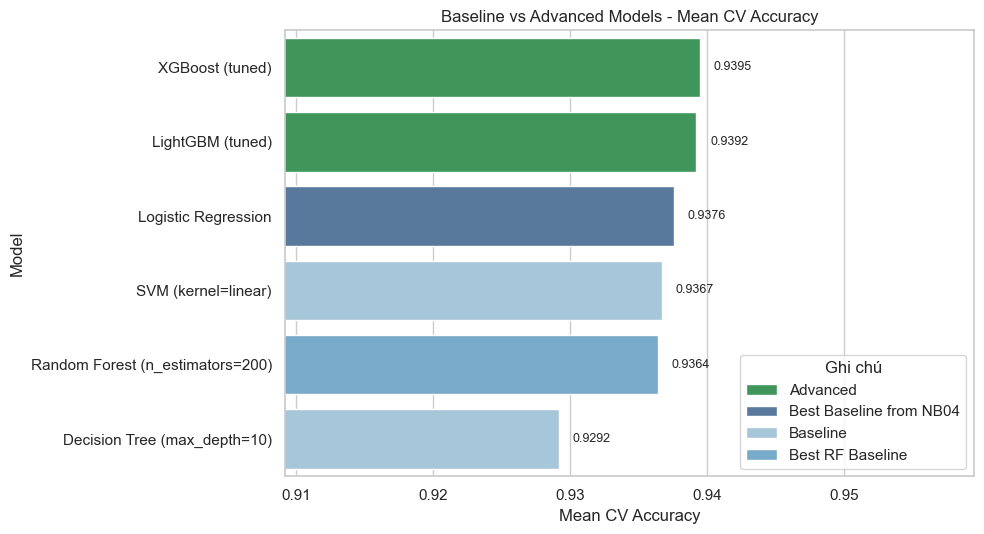

In [7]:
plt.figure(figsize=(10, 5.5))
sns.barplot(
    data=all_models_df,
    x="Accuracy_mean",
    y="Model",
    hue="Ghi chú",
    dodge=False,
    palette={"Baseline": "#9ecae1", "Best Baseline from NB04": "#4c78a8", "Best RF Baseline": "#6baed6", "Advanced": "#31a354"},
)
plt.title("Baseline vs Advanced Models - Mean CV Accuracy")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Model")
plt.xlim(
    max(0.0, all_models_df["Accuracy_mean"].min() - 0.02),
    min(1.0, all_models_df["Accuracy_mean"].max() + 0.02),
)
for idx, row in all_models_df.iterrows():
    plt.text(
        row["Accuracy_mean"] + 0.001,
        idx,
        f"{row['Accuracy_mean']:.4f}",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig('../scripts/img/05_model_advanced/05_model_advanced_fig3.png', dpi=150, bbox_inches='tight')
plt.show()


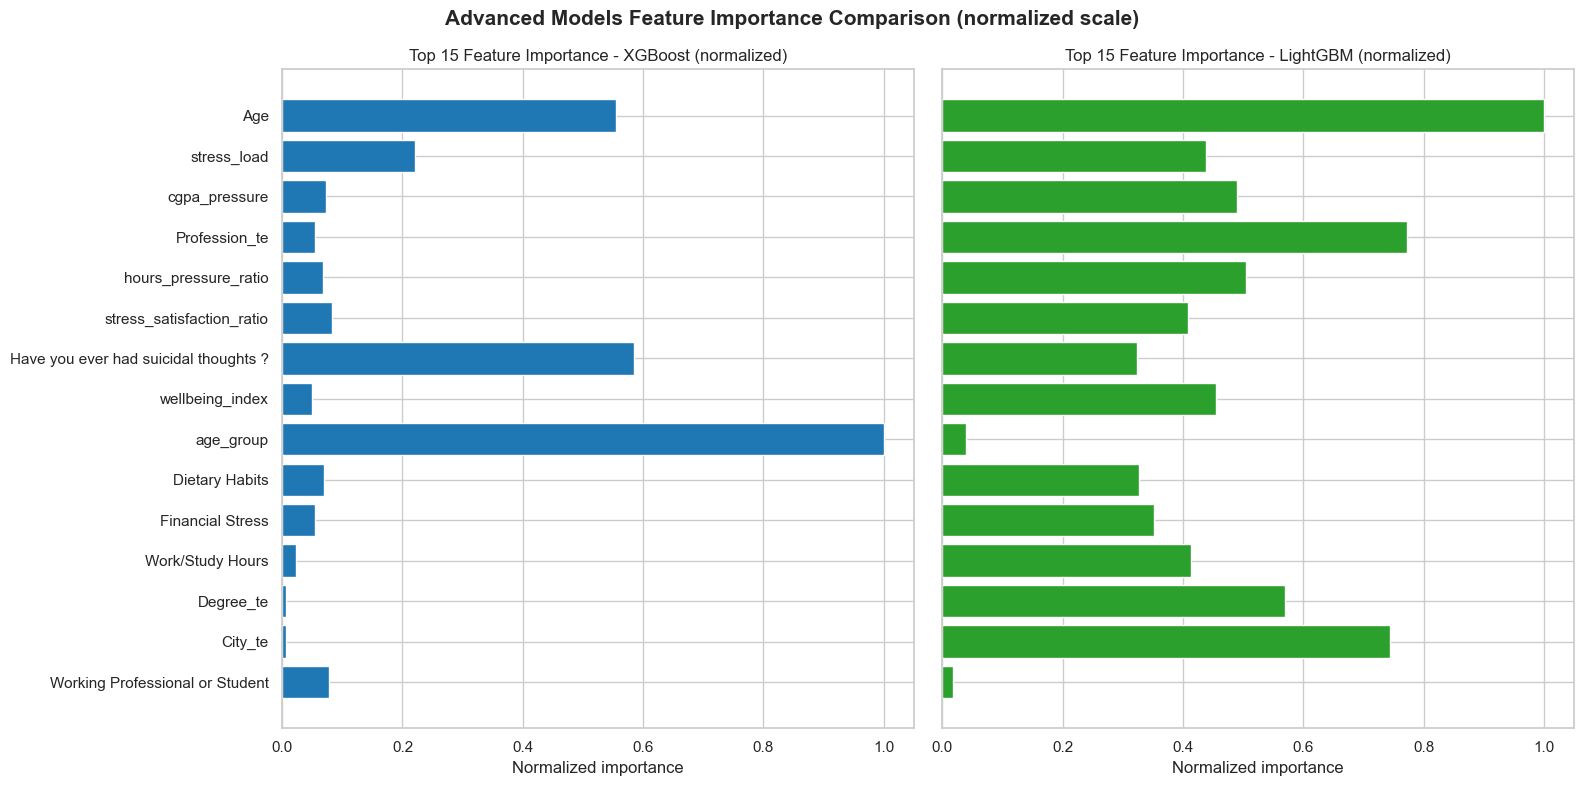

Shared top-10 features between XGBoost and LightGBM: Age, cgpa_pressure, hours_pressure_ratio, stress_load, stress_satisfaction_ratio


,feature,XGBoost,LightGBM,XGBoost_norm,LightGBM_norm,XGBoost_rank,LightGBM_rank,mean_rank
0,Age,0.1858,963,0.5544,1.0000,3,1,2.0
14,stress_load,0.0737,422,0.2200,0.4382,4,8,6.0
19,cgpa_pressure,0.0241,471,0.0720,0.4891,7,6,6.5
12,Profession_te,0.0183,743,0.0546,0.7715,11,2,6.5
17,hours_pressure_ratio,0.0228,486,0.0679,0.5047,9,5,7.0
16,stress_satisfaction_ratio,0.0279,393,0.0833,0.4081,5,10,7.5
5,Have you ever had suicidal thoughts ?,0.1960,311,0.5849,0.3229,2,14,8.0
15,wellbeing_index,0.0167,438,0.0498,0.4548,12,7,9.5
21,age_group,0.3352,38,1.0000,0.0395,1,19,10.0
4,Dietary Habits,0.0230,314,0.0687,0.3261,8,13,10.5


In [8]:
best_xgb_model = build_xgb_classifier(**best_xgb_params)
best_lgbm_model = build_lgbm_classifier(**best_lgbm_params)

best_xgb_model.fit(X, y)
best_lgbm_model.fit(X, y)

advanced_feature_importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "XGBoost": best_xgb_model.feature_importances_,
        "LightGBM": best_lgbm_model.feature_importances_,
    }
)

advanced_feature_importance_df["XGBoost_norm"] = (
    advanced_feature_importance_df["XGBoost"]
    / advanced_feature_importance_df["XGBoost"].max()
)
advanced_feature_importance_df["LightGBM_norm"] = (
    advanced_feature_importance_df["LightGBM"]
    / advanced_feature_importance_df["LightGBM"].max()
)
advanced_feature_importance_df["XGBoost_rank"] = (
    advanced_feature_importance_df["XGBoost"].rank(ascending=False, method="min").astype(int)
)
advanced_feature_importance_df["LightGBM_rank"] = (
    advanced_feature_importance_df["LightGBM"].rank(ascending=False, method="min").astype(int)
)
advanced_feature_importance_df["mean_rank"] = advanced_feature_importance_df[
    ["XGBoost_rank", "LightGBM_rank"]
].mean(axis=1)

top_features = (
    advanced_feature_importance_df.sort_values(
        by=["mean_rank", "XGBoost_rank", "LightGBM_rank"]
    )
    .head(15)
    .iloc[::-1]
)

top10_xgb = set(
    advanced_feature_importance_df.nsmallest(10, "XGBoost_rank")["feature"]
)
top10_lgbm = set(
    advanced_feature_importance_df.nsmallest(10, "LightGBM_rank")["feature"]
)
shared_top10_features = top10_xgb & top10_lgbm

comparison_table = advanced_feature_importance_df.sort_values(
    by=["mean_rank", "XGBoost_rank", "LightGBM_rank"]
)[
    [
        "feature",
        "XGBoost",
        "LightGBM",
        "XGBoost_norm",
        "LightGBM_norm",
        "XGBoost_rank",
        "LightGBM_rank",
        "mean_rank",
    ]
].head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

axes[0].barh(top_features["feature"], top_features["XGBoost_norm"], color="#1f77b4")
axes[0].set_title("Top 15 Feature Importance - XGBoost (normalized)")
axes[0].set_xlabel("Normalized importance")

axes[1].barh(top_features["feature"], top_features["LightGBM_norm"], color="#2ca02c")
axes[1].set_title("Top 15 Feature Importance - LightGBM (normalized)")
axes[1].set_xlabel("Normalized importance")

plt.suptitle(
    "Advanced Models Feature Importance Comparison (normalized scale)",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig('../scripts/img/05_model_advanced/advanced_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

print(
    "Shared top-10 features between XGBoost and LightGBM:",
    ", ".join(sorted(shared_top10_features))
)
display(comparison_table.round(4))


### Nhận xét 5.4

- Bảng tổng hợp cho thấy **XGBoost (tuned)** là mô hình tốt nhất của notebook với `Accuracy = 0.9395 ± 0.0016`, theo sau là **LightGBM (tuned)** với `0.9392 ± 0.0013`. Cả hai đều vượt baseline mạnh nhất là **Logistic Regression** (`0.9376 ± 0.0019`).
- Mức cải thiện không lớn (`+0.0019` cho XGBoost và `+0.0016` cho LightGBM so với baseline tốt nhất), nhưng nó xuất hiện nhất quán trên cả Accuracy và F1, nên có thể kết luận advanced models thực sự mang lại lợi ích thay vì chỉ dao động ngẫu nhiên.
- Ở phần feature importance, notebook không cộng trực tiếp raw importance của XGBoost và LightGBM nữa vì hai thư viện dùng thang đo khác nhau. Thay vào đó, phần so sánh được chuẩn hóa theo `normalized importance` và `mean rank`, nên việc đối chiếu giữa hai mô hình công bằng hơn.
- Danh sách `Shared top-10 features between XGBoost and LightGBM` cho thấy hai mô hình cùng nhấn mạnh vào `Age`, `cgpa_pressure`, `hours_pressure_ratio`, `stress_load`, `stress_satisfaction_ratio`. Đây đều là các biến gốc quan trọng hoặc engineered features, nên có thể xem notebook 03 đã tạo ra những tín hiệu thực sự hữu ích cho mô hình hóa.
- Bên cạnh phần giao nhau đó, các target-encoded features như `Profession_te`, `City_te`, `Degree_te` vẫn đứng khá cao trong `comparison_table`, đặc biệt ở phía LightGBM. Điều này cho thấy encoding cho high-cardinality features vẫn mang lại giá trị bổ sung dù mức độ quan trọng không hoàn toàn giống nhau giữa hai mô hình.
- Nếu cần chọn một mô hình duy nhất để chuyển sang notebook 06, XGBoost là lựa chọn hợp lý nhất vì đang đứng đầu về Accuracy và F1, trong khi LightGBM là phương án dự phòng rất sát nút.


In [9]:
best_model_row = all_models_df.iloc[0]
best_baseline_row = all_models_df[all_models_df["Ghi chú"].str.contains("Baseline")].iloc[0]
best_advanced_row = all_models_df[all_models_df["Ghi chú"] == "Advanced"].iloc[0]

display(
    Markdown(
        f'''
### Kết luận tự động

- Mô hình tốt nhất trong bảng so sánh hiện tại là **{best_model_row["Model"]}** với **Accuracy = {best_model_row["Accuracy_mean"]:.4f} ± {best_model_row["Accuracy_std"]:.4f}**.
- Baseline mạnh nhất để làm mốc là **{best_baseline_row["Model"]}** với **Accuracy = {best_baseline_row["Accuracy_mean"]:.4f} ± {best_baseline_row["Accuracy_std"]:.4f}**.
- Advanced model tốt nhất là **{best_advanced_row["Model"]}** với **Accuracy = {best_advanced_row["Accuracy_mean"]:.4f} ± {best_advanced_row["Accuracy_std"]:.4f}**.
- Mức cải thiện của advanced tốt nhất so với baseline tốt nhất là **{best_advanced_row["Accuracy_mean"] - best_baseline_row["Accuracy_mean"]:+.4f}** điểm accuracy.
        '''
    )
)



### Kết luận tự động

- Mô hình tốt nhất trong bảng so sánh hiện tại là **XGBoost (tuned)** với **Accuracy = 0.9395 ± 0.0016**.
- Baseline mạnh nhất để làm mốc là **Logistic Regression** với **Accuracy = 0.9376 ± 0.0019**.
- Advanced model tốt nhất là **XGBoost (tuned)** với **Accuracy = 0.9395 ± 0.0016**.
- Mức cải thiện của advanced tốt nhất so với baseline tốt nhất là **+0.0019** điểm accuracy.
        

## 5.5 Kết luận

Notebook này đã thực hiện các giai đoạn advanced modeling:
- Train **XGBoost** với 5-Fold CV
- Tune thủ công `max_depth`, `learning_rate`, `n_estimators`
- Train **LightGBM** với 5-Fold CV
- Tune thủ công `num_leaves`, `learning_rate`, `n_estimators`
- So sánh trực tiếp với các baseline models từ notebook 04
- Chuẩn hóa lại phần so sánh feature importance giữa hai mô hình
- Tạo bảng tổng hợp để chọn mô hình mạnh nhất cho notebook 06

Kết quả cuối cùng của notebook:
- **XGBoost (tuned)** là mô hình tốt nhất với `Accuracy = 0.9395 ± 0.0016`
- **LightGBM (tuned)** đứng thứ hai với `Accuracy = 0.9392 ± 0.0013`
- Advanced model tốt nhất cải thiện `+0.0019` điểm accuracy so với baseline mạnh nhất

Đầu ra quan trọng:
- `best_xgb_params`
- `best_lgbm_params`
- `report_table_df`
- `comparison_table`
- `docs/advanced_feature_importance.png`

Với kết quả hiện tại, **XGBoost** là ứng viên nên được chuyển sang notebook 06 để làm evaluation chi tiết, SHAP analysis và tạo prediction trên test set.
